In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("india_housing_prices.csv")

In [3]:
df.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [4]:
df.isnull().sum()

ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

In [5]:
df.duplicated().sum()

0

In [6]:
df.columns


Index(['ID', 'State', 'City', 'Locality', 'Property_Type', 'BHK',
       'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built',
       'Furnished_Status', 'Floor_No', 'Total_Floors', 'Age_of_Property',
       'Nearby_Schools', 'Nearby_Hospitals', 'Public_Transport_Accessibility',
       'Parking_Space', 'Security', 'Amenities', 'Facing', 'Owner_Type',
       'Availability_Status'],
      dtype='object')

In [7]:
# Numarical Columns
num_cols = [
    'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt',
    'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property'
]

In [8]:
# Catagorical Columns
cat_cols = [
    'State', 'City', 'Locality', 'Property_Type', 'BHK',
    'Furnished_Status', 'Nearby_Schools', 'Nearby_Hospitals',
    'Public_Transport_Accessibility', 'Parking_Space',
    'Security', 'Amenities', 'Facing', 'Owner_Type',
    'Availability_Status'
]

In [9]:
df['Price_per_SqFt'] = df['Price_in_Lakhs'] * 100000 / df['Size_in_SqFt']

In [10]:
current_year = 2026
df['Age_of_Property'] = current_year - df['Year_Built']

In [11]:
df['School_Density_Score'] = (
    df['Nearby_Schools'].astype(int) +
    df['Nearby_Hospitals'].astype(int)
)

In [12]:
def good_investment(row):
    if (
        row['Price_per_SqFt'] < df['Price_per_SqFt'].mean() and
        row['Age_of_Property'] < 10 and
        row['School_Density_Score'] > df['School_Density_Score'].mean()
    ):
        return 1
    return 0

df['Good_Investment'] = df.apply(good_investment, axis=1)

In [13]:
df.head(10)

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status,School_Density_Score,Good_Investment
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,10332.489451,1990,...,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move,13,0
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,8270.727580,2008,...,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction,9,0
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,5046.403075,1997,...,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move,17,0
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,10955.490697,1991,...,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move,12,0
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,3792.245490,2002,...,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move,13,0
5,6,West Bengal,Durgapur,Locality_246,Apartment,4,3500,135.28,3865.142857,2020,...,7,Low,Yes,Yes,"Playground, Clubhouse",West,Broker,Ready_to_Move,14,1
6,7,Tamil Nadu,Coimbatore,Locality_254,Independent House,3,4826,318.12,6591.794447,2016,...,6,High,No,Yes,"Clubhouse, Garden, Playground",North,Builder,Under_Construction,9,0
7,8,Chhattisgarh,Bilaspur,Locality_490,Independent House,5,4252,141.39,3325.258702,2021,...,10,High,Yes,Yes,"Gym, Pool, Clubhouse, Playground",North,Builder,Under_Construction,20,1
8,9,Delhi,New Delhi,Locality_232,Villa,4,2678,189.16,7063.480209,2003,...,5,Low,No,Yes,"Garden, Clubhouse, Playground",South,Broker,Under_Construction,12,0
9,10,Jharkhand,Ranchi,Locality_122,Villa,2,1393,187.42,13454.414932,2011,...,3,High,Yes,No,"Clubhouse, Playground, Garden, Gym",East,Owner,Ready_to_Move,6,0


In [14]:
df.dtypes

ID                                  int64
State                              object
City                               object
Locality                           object
Property_Type                      object
BHK                                 int64
Size_in_SqFt                        int64
Price_in_Lakhs                    float64
Price_per_SqFt                    float64
Year_Built                          int64
Furnished_Status                   object
Floor_No                            int64
Total_Floors                        int64
Age_of_Property                     int64
Nearby_Schools                      int64
Nearby_Hospitals                    int64
Public_Transport_Accessibility     object
Parking_Space                      object
Security                           object
Amenities                          object
Facing                             object
Owner_Type                         object
Availability_Status                object
School_Density_Score              

In [15]:
df['Good_Investment'].value_counts()

Good_Investment
0    230906
1     19094
Name: count, dtype: int64

In [16]:
# Condition: where Floor_No is greater than Total_Floors
mask = df['Floor_No'] > df['Total_Floors']

# Swap the values
df.loc[mask, ['Floor_No', 'Total_Floors']] = \
df.loc[mask, ['Total_Floors', 'Floor_No']].values

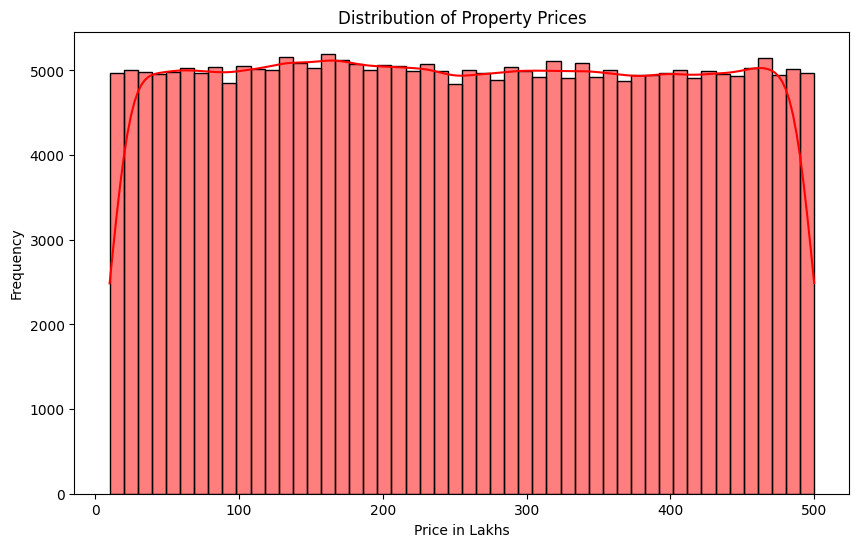

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.histplot(df['Price_in_Lakhs'], bins=50, kde=True, color='red')

plt.title("Distribution of Property Prices")
plt.xlabel("Price in Lakhs")
plt.ylabel("Frequency")

plt.show()

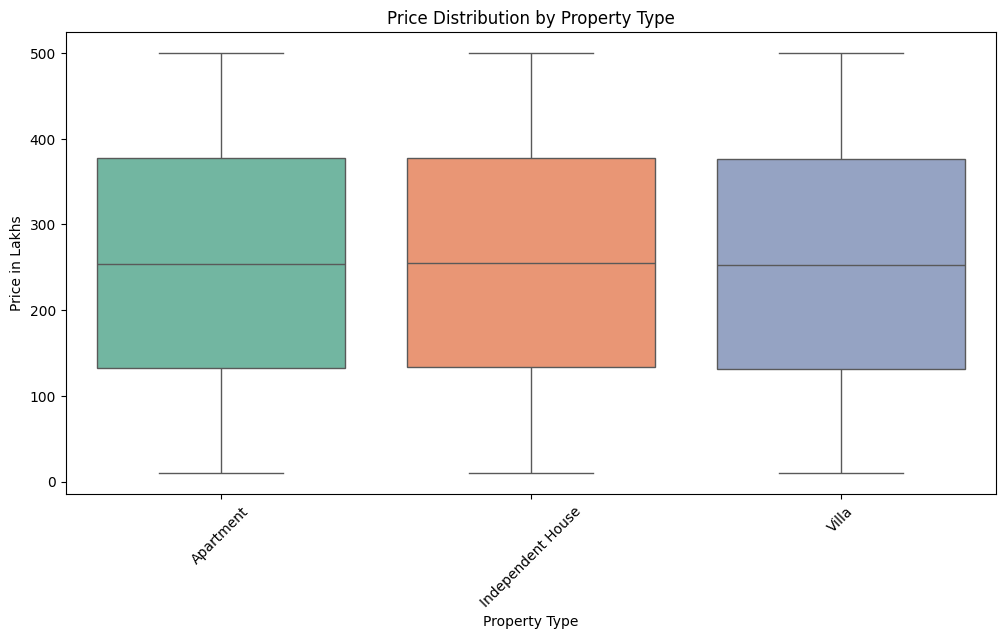

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.boxplot(x='Property_Type', y='Price_in_Lakhs', 
            data=df, palette='Set2')

plt.title("Price Distribution by Property Type")
plt.xlabel("Property Type")
plt.ylabel("Price in Lakhs")
plt.xticks(rotation=45)

plt.show()

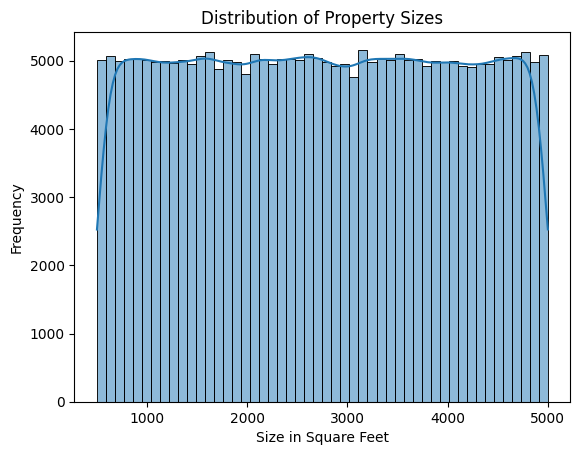

In [19]:
#2. Distribution of Property Sizes

sns.histplot(df['Size_in_SqFt'], bins=50, kde=True)
plt.title("Distribution of Property Sizes")
plt.xlabel("Size in Square Feet")
plt.ylabel("Frequency")
plt.show()

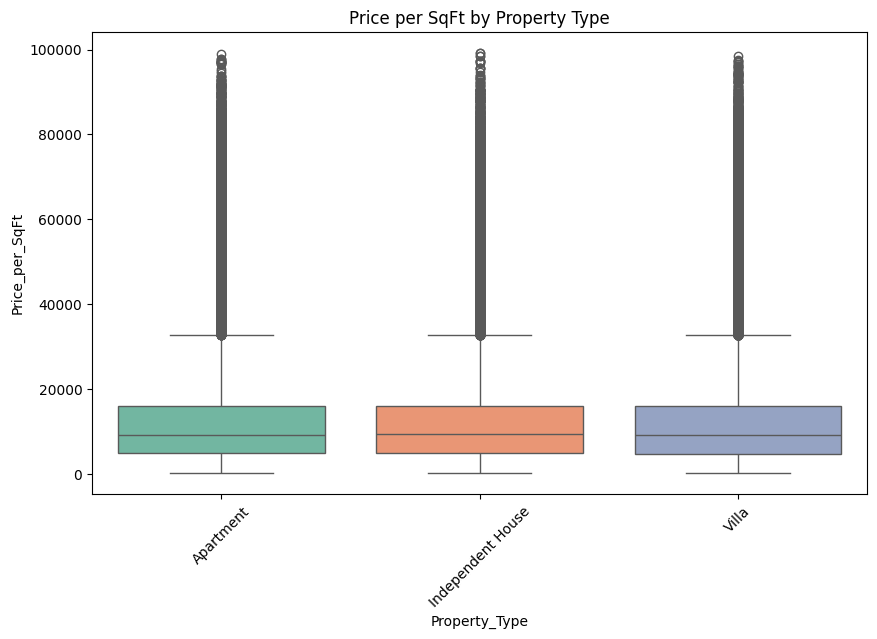

In [20]:
#3. Price per SqFt vs Property Type

plt.figure(figsize=(10,6))
sns.boxplot(x='Property_Type', y='Price_per_SqFt', data=df, palette='Set2')
plt.xticks(rotation=45)
plt.title("Price per SqFt by Property Type")
plt.show()

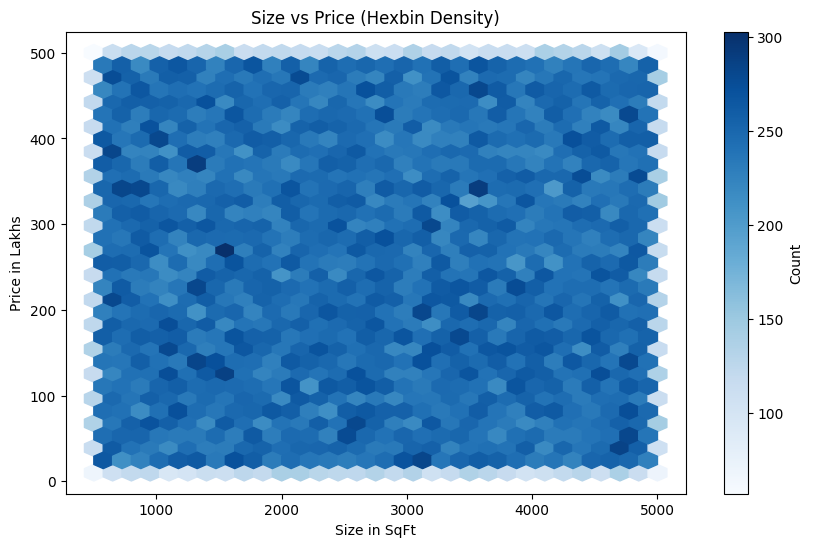

In [21]:
#4. Size vs Price

plt.figure(figsize=(10,6))
plt.hexbin(df['Size_in_SqFt'], df['Price_in_Lakhs'], gridsize=30, cmap='Blues')
plt.colorbar(label='Count')
plt.xlabel("Size in SqFt")
plt.ylabel("Price in Lakhs")
plt.title("Size vs Price (Hexbin Density)")
plt.show()

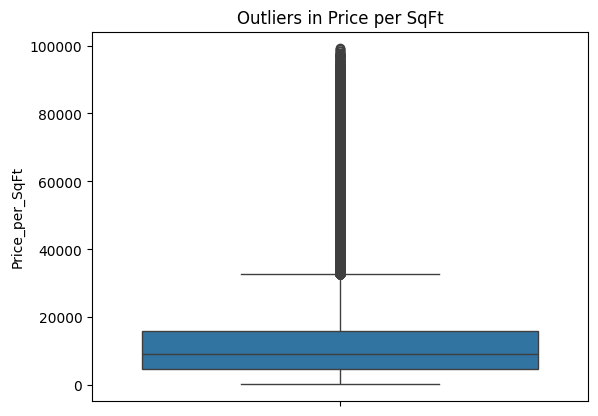

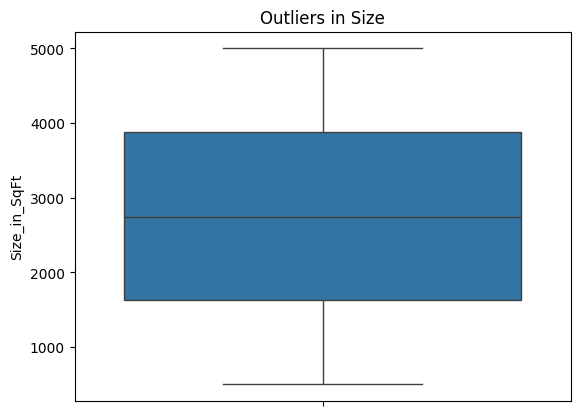

In [22]:
sns.boxplot(df['Price_per_SqFt'])
plt.title("Outliers in Price per SqFt")
plt.show()

sns.boxplot(df['Size_in_SqFt'])
plt.title("Outliers in Size")
plt.show()

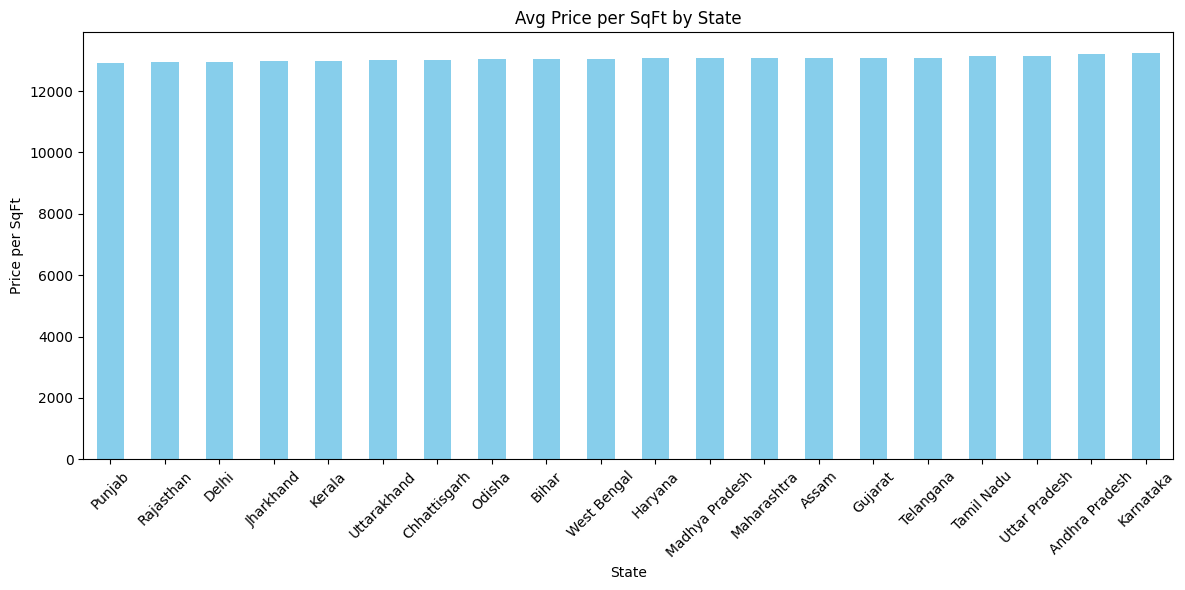

In [23]:
#6. Avg Price per SqFt by State

plt.figure(figsize=(12,6))
data = df.groupby('State')['Price_per_SqFt'].mean().sort_values()

data.plot(kind='bar', color='skyblue')

plt.xticks(rotation=45)
plt.title("Avg Price per SqFt by State")
plt.xlabel("State")
plt.ylabel("Price per SqFt")

plt.tight_layout()
plt.show()

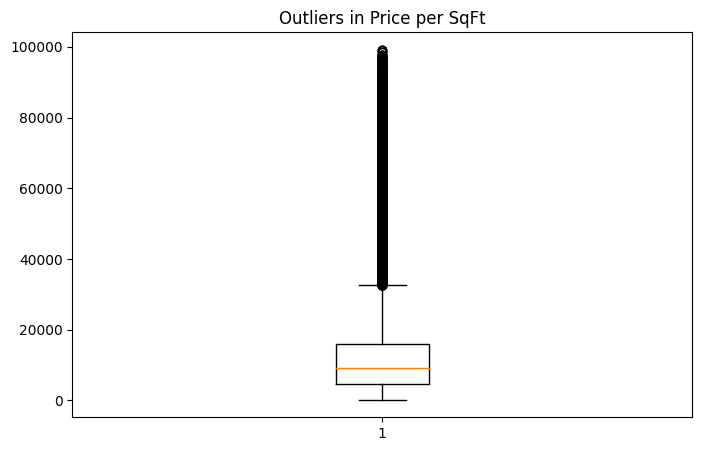

In [24]:
plt.figure(figsize=(8,5))
plt.boxplot(df['Price_per_SqFt'])
plt.title("Outliers in Price per SqFt")
plt.show()

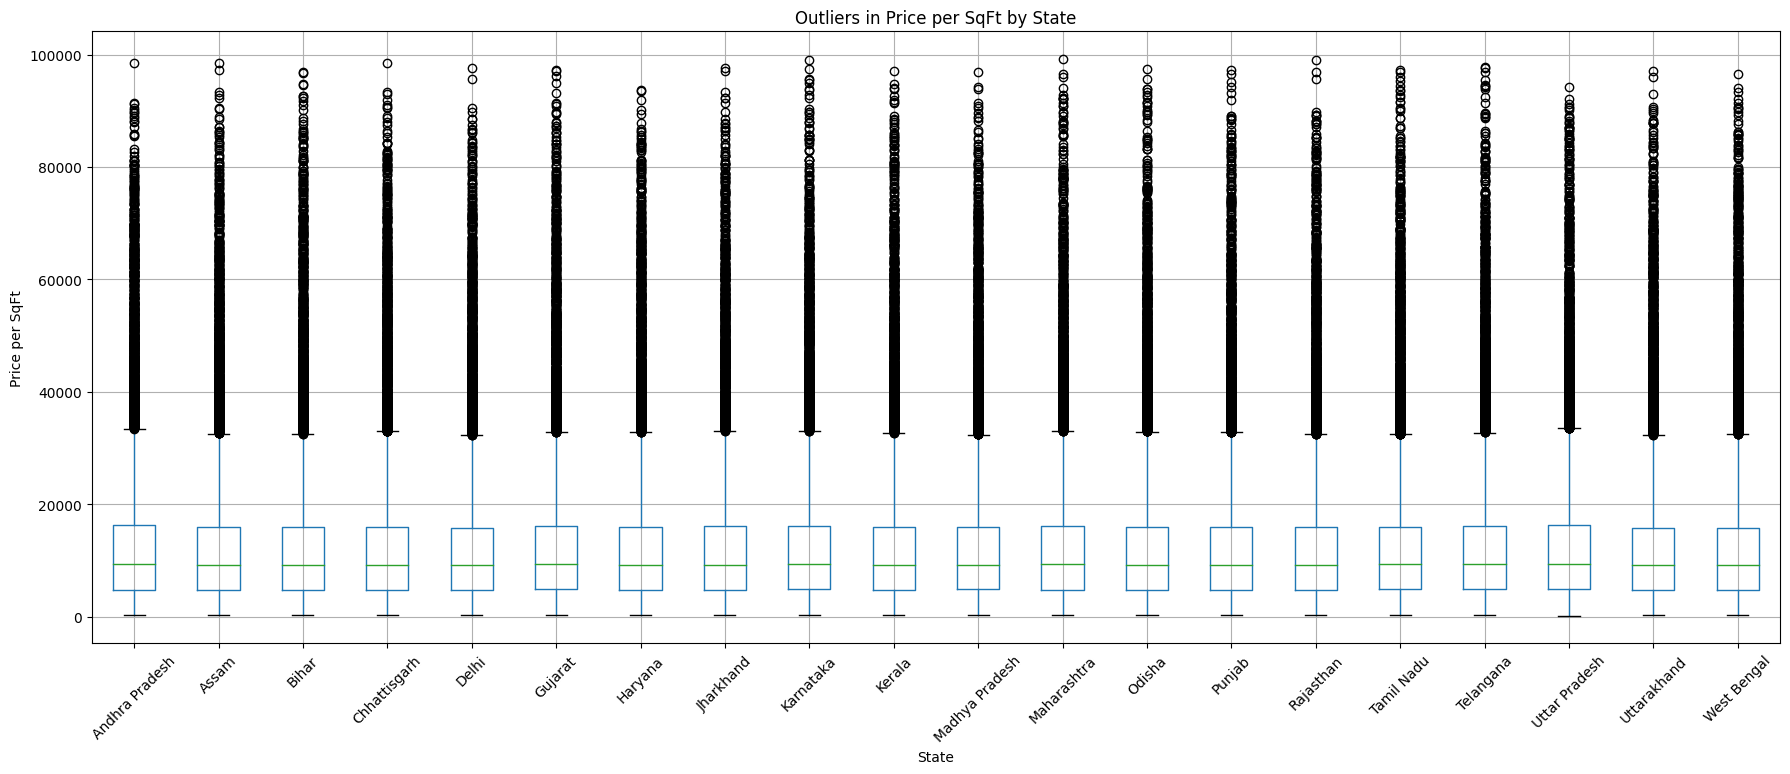

In [ ]:

# Make figure bigger directly in boxplot
df.boxplot(column='Price_per_SqFt', by='State', rot=45, figsize=(18,8))

plt.title("Outliers in Price per SqFt by State")
plt.suptitle("")  # remove extra title
plt.xlabel("State")
plt.ylabel("Price per SqFt")

plt.tight_layout()
plt.show()

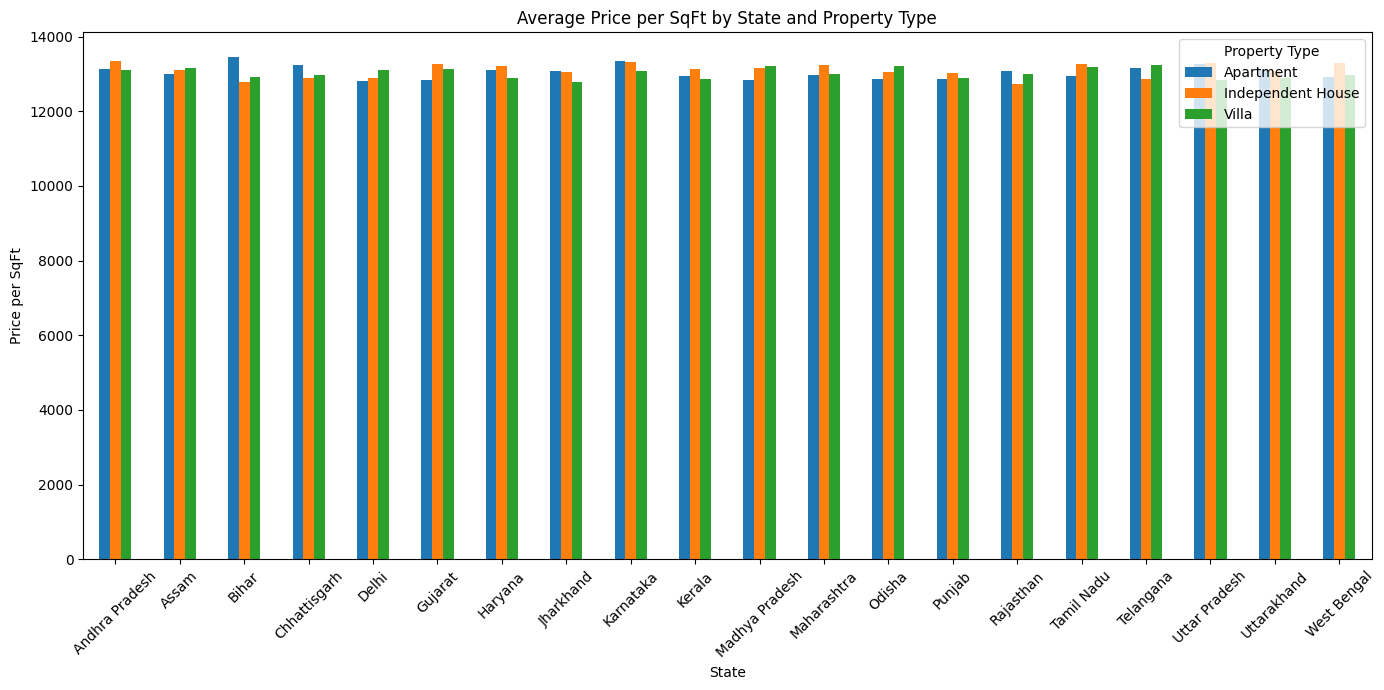

In [26]:
# 6. Average Price per SqFt by State and Property Type

data = df.groupby(['State', 'Property_Type'])['Price_per_SqFt'].mean().unstack()

data.plot(kind='bar', figsize=(14,7))

plt.title("Average Price per SqFt by State and Property Type")
plt.xlabel("State")
plt.ylabel("Price per SqFt")
plt.xticks(rotation=45)

plt.legend(title='Property Type')
plt.tight_layout()

plt.show()

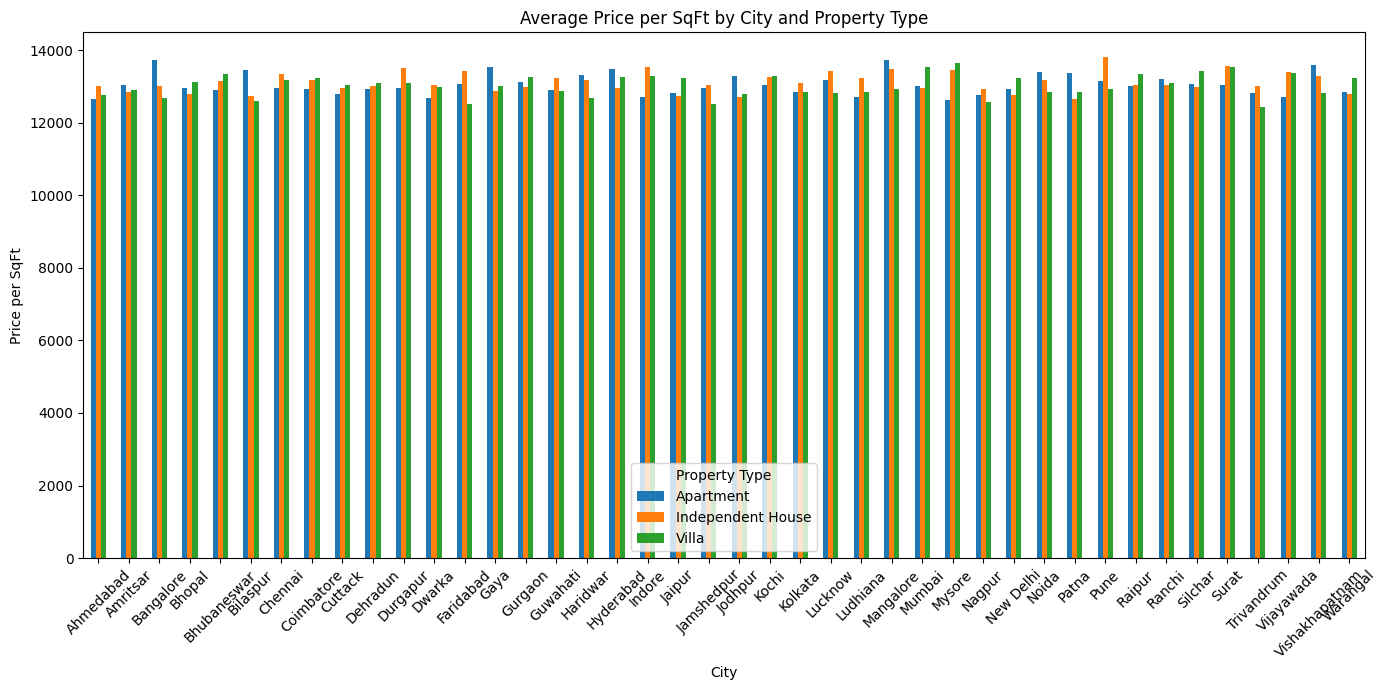

In [27]:
# 7. Average Property Price by City

data = df.groupby(['City', 'Property_Type'])['Price_per_SqFt'].mean().unstack()

data.plot(kind='bar', figsize=(14,7))

plt.title("Average Price per SqFt by City and Property Type")
plt.xlabel("City")
plt.ylabel("Price per SqFt")
plt.xticks(rotation=45)

plt.legend(title='Property Type')
plt.tight_layout()

plt.show()

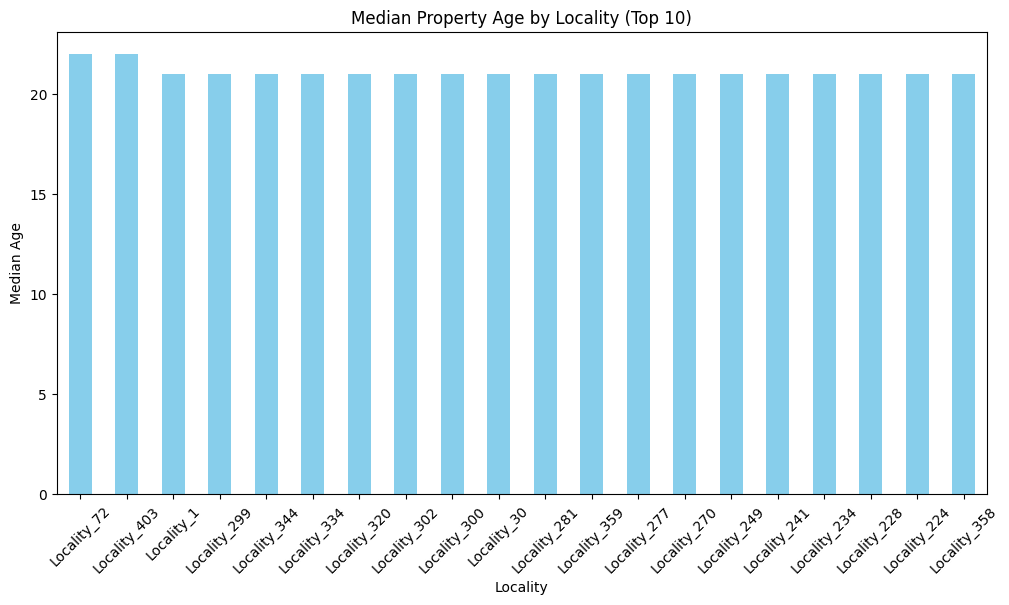

In [28]:
# 8. Median Age of Properties by Locality

data = df.groupby('Locality')['Age_of_Property'].median().sort_values(ascending=False).head(20)
plt.figure(figsize = (12,6))
data.plot(kind = 'bar',color='skyblue')

plt.title("Median Property Age by Locality (Top 10)")
plt.xlabel("Locality")
plt.ylabel("Median Age")
plt.xticks(rotation=45)

plt.show()

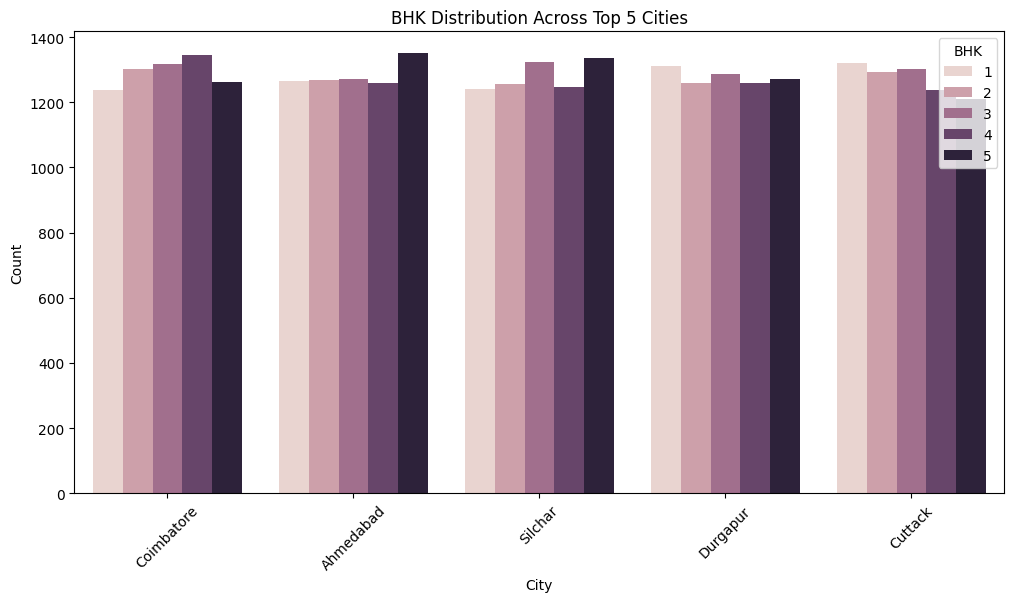

In [29]:
# 9. BHK Distribution Across Cities

plt.figure(figsize=(12,6))
sns.countplot(x='City', hue ='BHK', data=df,order=df['City'].value_counts().index[:5])

plt.title("BHK Distribution Across Top 5 Cities")
plt.xlabel("City")
plt.ylabel("Count")
plt.xticks(rotation=45) 

plt.show()

Index(['Locality_207', 'Locality_416', 'Locality_246', 'Locality_359',
       'Locality_387'],
      dtype='object', name='Locality')


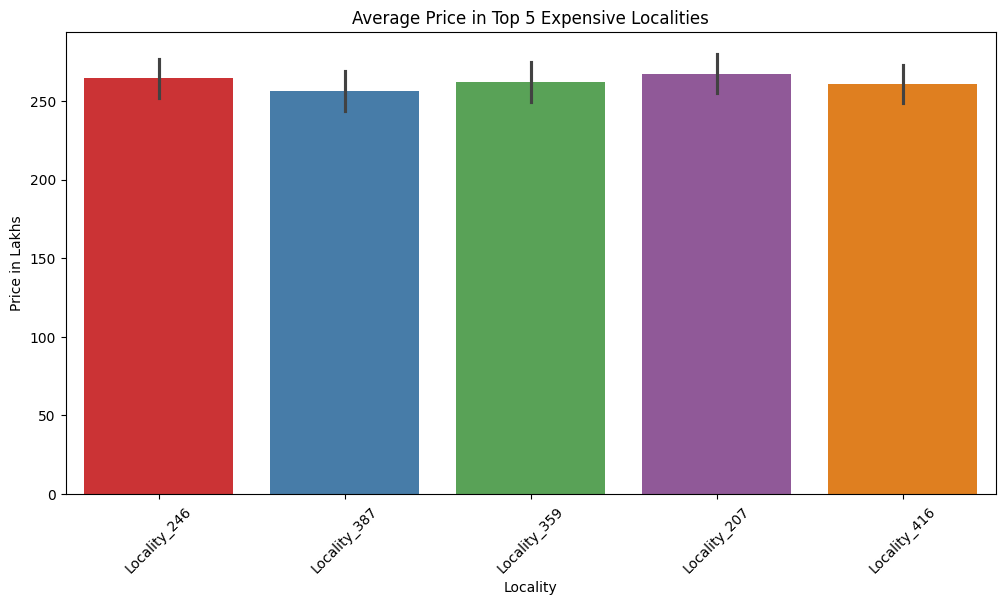

In [30]:
# 10. Price Trends for Top 5 Expensive Localities

top_localities = df.groupby('Locality')['Price_per_SqFt'].mean().sort_values(ascending=False).head(5).index
print(top_localities)

plt.figure(figsize=(12,6))

sns.barplot(
    data=df[df['Locality'].isin(top_localities)],
    x='Locality',
    y='Price_in_Lakhs',
    estimator='mean',
    palette='Set1'
)

plt.title("Average Price in Top 5 Expensive Localities")
plt.xlabel("Locality")
plt.ylabel("Price in Lakhs")
plt.xticks(rotation=45)

plt.show()

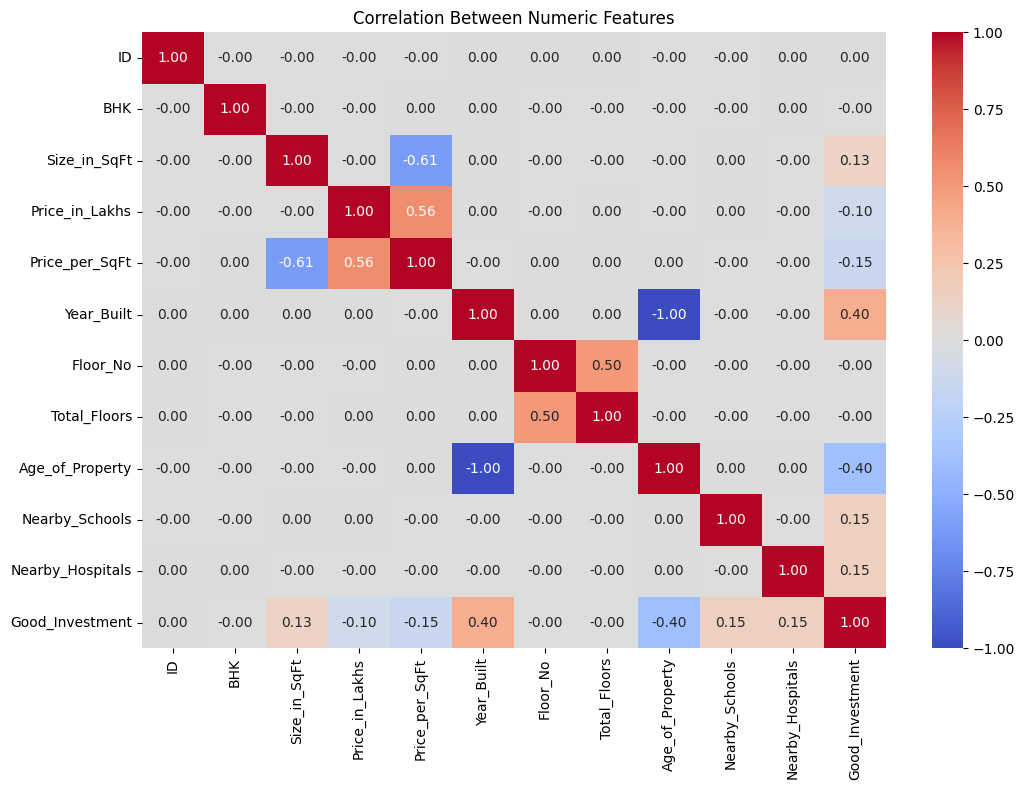

In [31]:
# 11. Correlation between numeric features


# Select numeric columns
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Correlation matrix
corr_matrix = num_cols.corr()

# Plot heatmap
plt.figure(figsize=(12,8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Between Numeric Features")
plt.show()

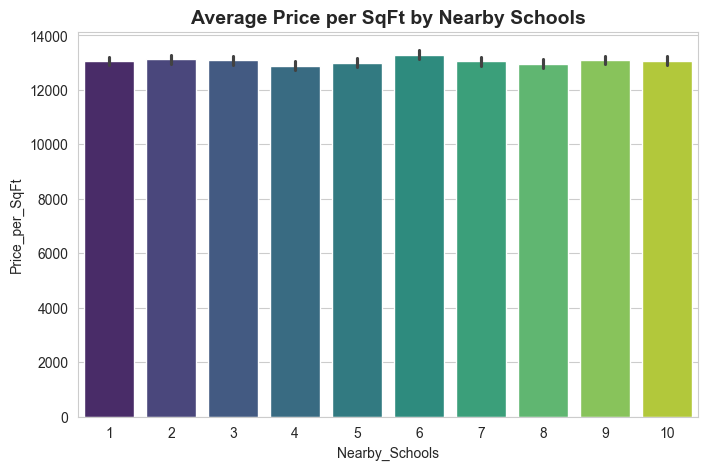

In [32]:
# 12. Nearby Schools vs Price per SqFt

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.barplot(
    data=df, 
    x='Nearby_Schools', 
    y='Price_per_SqFt',
    palette='viridis'   # gradient color
)
plt.title("Average Price per SqFt by Nearby Schools", fontsize=14, weight='bold')
plt.show()

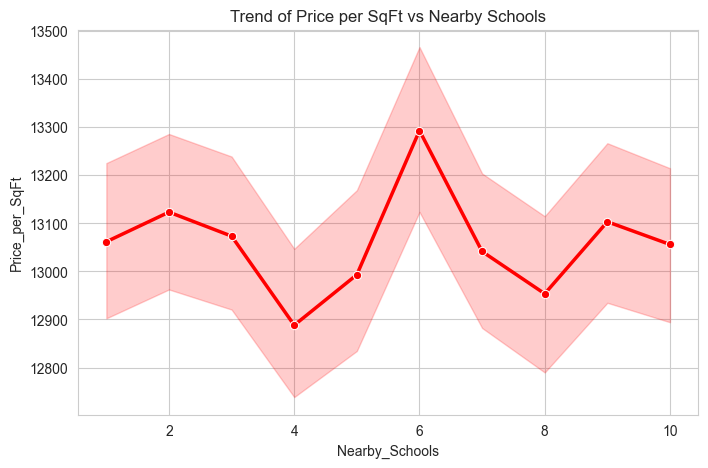

In [33]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df, 
    x='Nearby_Schools', 
    y='Price_per_SqFt', 
    estimator='mean',
    color='red',          # change color
    marker='o',           # add points
    linewidth=2.5         # thicker line
)
plt.title("Trend of Price per SqFt vs Nearby Schools")
plt.grid(True)
plt.show()

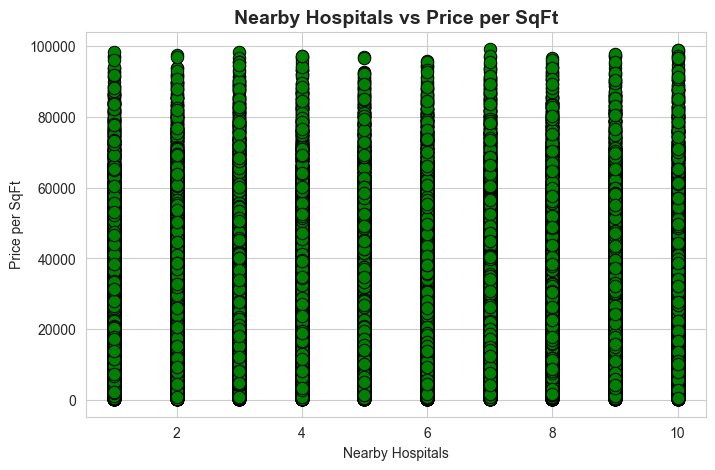

In [34]:
# 13. Nearby Hospitals vs Price per SqFt

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.scatterplot(
    data=df, 
    x='Nearby_Hospitals', 
    y='Price_per_SqFt',
    color='green',
    s=80,              # marker size
    edgecolor='black'  # border for clarity
)

plt.title("Nearby Hospitals vs Price per SqFt", fontsize=14, weight='bold')
plt.xlabel("Nearby Hospitals")
plt.ylabel("Price per SqFt")
plt.show()

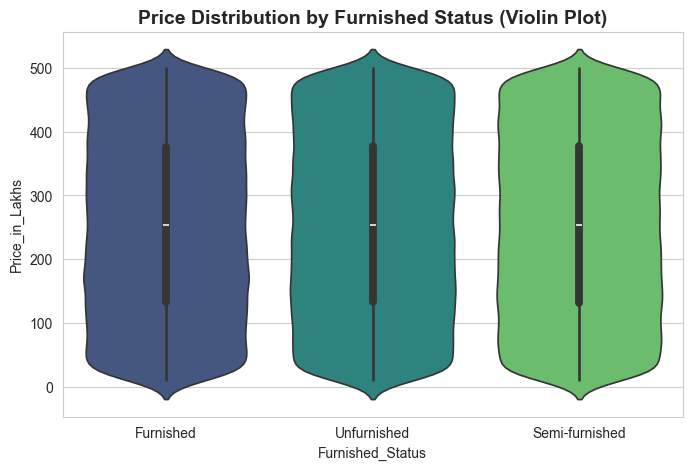

In [35]:
# 14. Price vs Furnished Status

sns.set_style("whitegrid")

plt.figure(figsize=(8,5))
sns.violinplot(
    data=df, 
    x='Furnished_Status', 
    y='Price_in_Lakhs',
    palette='viridis'
)

plt.title("Price Distribution by Furnished Status (Violin Plot)", fontsize=14, weight='bold')
plt.show()

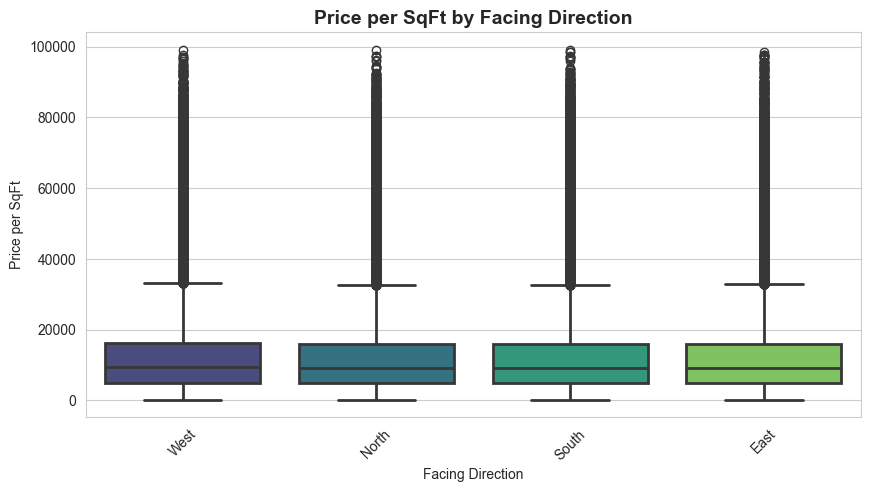

In [36]:
#15. Price per SqFt vs Facing Direction

sns.set_style("whitegrid")

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df, 
    x='Facing', 
    y='Price_per_SqFt',
    palette='viridis',   # smooth gradient
    linewidth=2
)

plt.title("Price per SqFt by Facing Direction", fontsize=14, weight='bold')
plt.xlabel("Facing Direction")
plt.ylabel("Price per SqFt")
plt.xticks(rotation=45)
plt.show()

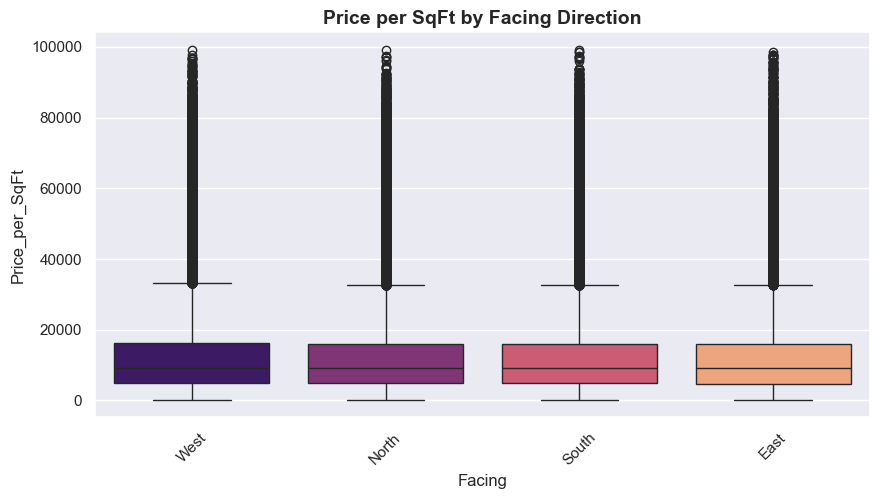

In [37]:
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10,5))
sns.boxplot(
    data=df, 
    x='Facing', 
    y='Price_per_SqFt',
    palette='magma'
)

plt.title("Price per SqFt by Facing Direction", fontsize=14, weight='bold')
plt.xticks(rotation=45)
plt.show()

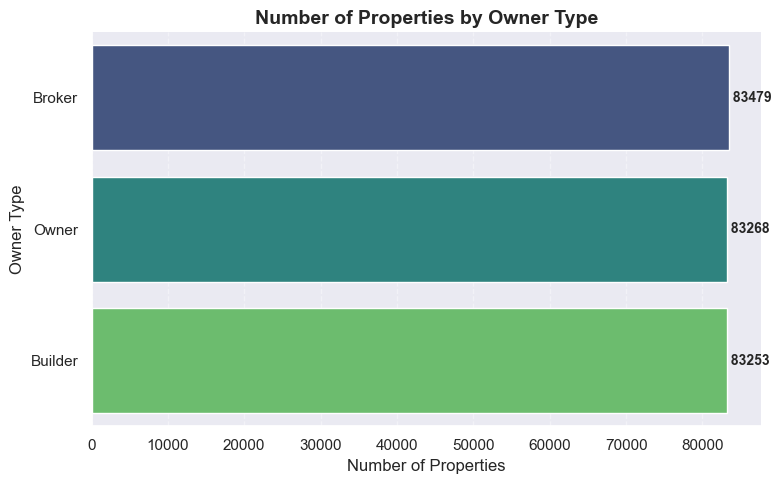

In [50]:
#16. How many properties belong to each owner type?

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=owner_counts.values,
    y=owner_counts.index,
    palette="viridis"
)

plt.title("Number of Properties by Owner Type", fontsize=14, fontweight='bold')
plt.xlabel("Number of Properties")
plt.ylabel("Owner Type")

# Add labels
for i, v in enumerate(owner_counts.values):
    plt.text(v, i, f" {v}", va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

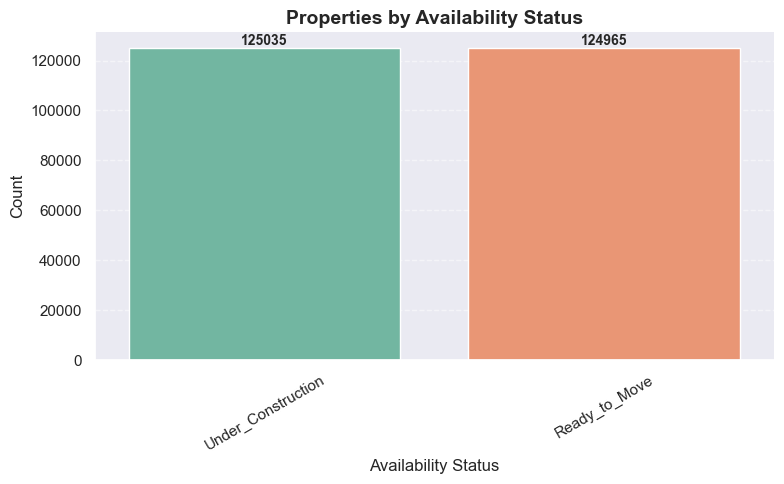

In [48]:
#17. How many properties are available under each availability status?

import matplotlib.pyplot as plt
import seaborn as sns

availability_counts = df['Availability_Status'].value_counts()

plt.figure(figsize=(8,5))

# Use a colorful palette
palette = sns.color_palette("Set2", len(availability_counts))

ax = sns.countplot(
    data=df,
    x='Availability_Status',
    order=availability_counts.index,
    palette=palette
)

# Add title and labels
plt.title("Properties by Availability Status", fontsize=14, fontweight='bold')
plt.xlabel("Availability Status", fontsize=12)
plt.ylabel("Count", fontsize=12)

# Rotate labels for clarity
plt.xticks(rotation=30)

# Add value labels on bars
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom',
                fontsize=10, fontweight='bold')

# Add grid for style
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Remove top/right borders (clean look)
sns.despine()

plt.tight_layout()
plt.show()

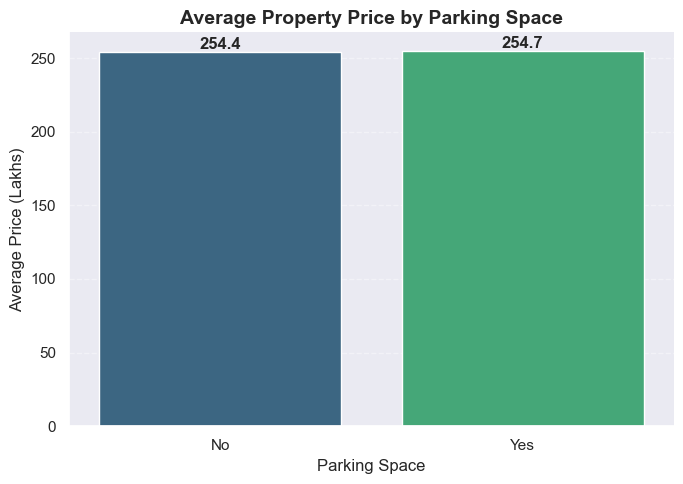

In [52]:
# 18. Does parking space affect property price?

avg_price = df.groupby('Parking_Space')['Price_in_Lakhs'].mean().sort_index()

plt.figure(figsize=(7,5))

ax = sns.barplot(
    x=avg_price.index,
    y=avg_price.values,
    palette="viridis"
)

plt.title("Average Property Price by Parking Space", fontsize=14, fontweight='bold')
plt.xlabel("Parking Space")
plt.ylabel("Average Price (Lakhs)")

# Add labels
for i, v in enumerate(avg_price.values):
    plt.text(i, v, f"{v:.1f}", ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.4)
sns.despine()

plt.tight_layout()
plt.show()

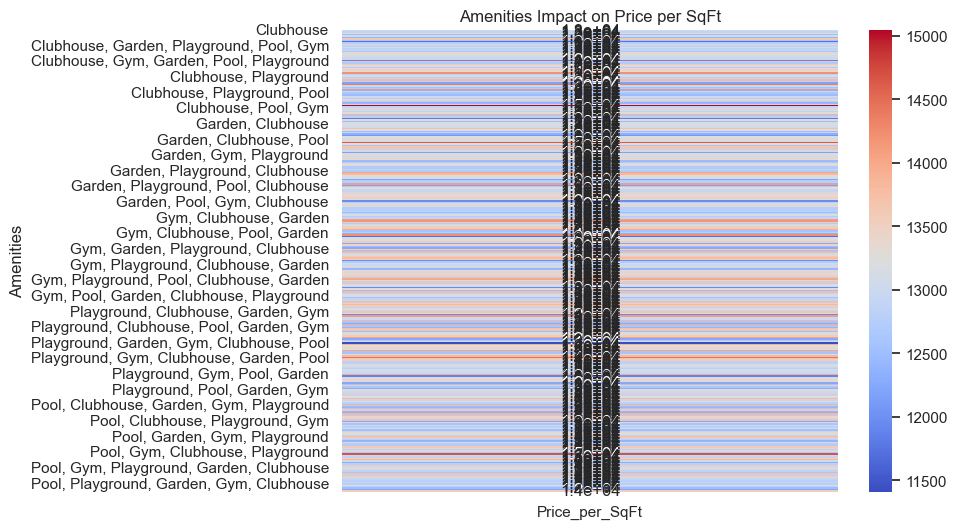

In [ ]:
# # 19. How do amenities affect price per sq ft?

pivot = df.pivot_table(values='Price_per_SqFt', index='Amenities', aggfunc='mean')

plt.figure(figsize=(8,6))
sns.heatmap(pivot, annot=True, cmap='coolwarm')

plt.title("Amenities Impact on Price per SqFt")
plt.show()

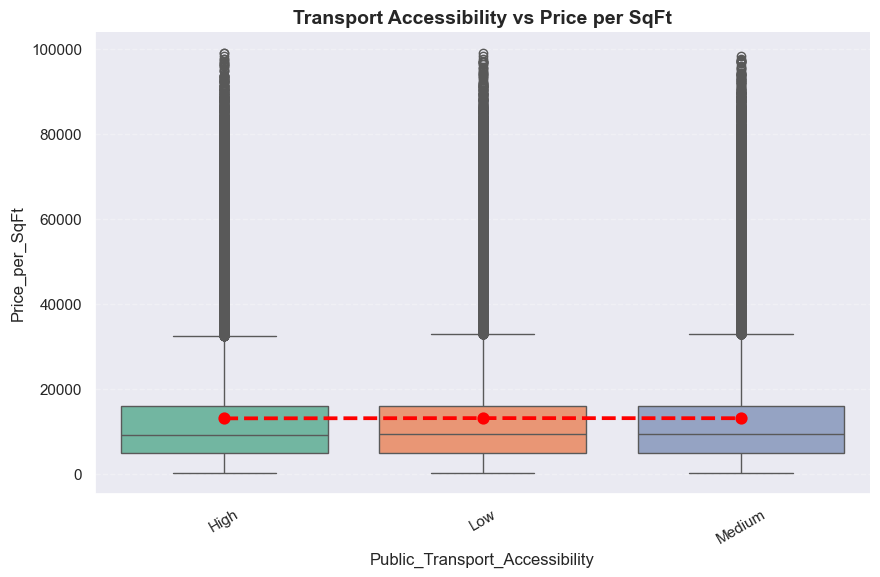

In [54]:
# 20. How does public transport accessibility relate to price per sq ft?

plt.figure(figsize=(10,6))

ax = sns.boxplot(
    data=df,
    x='Public_Transport_Accessibility',
    y='Price_per_SqFt',
    palette="Set2"
)

# Add mean line
sns.pointplot(
    data=df,
    x='Public_Transport_Accessibility',
    y='Price_per_SqFt',
    color='red',
    linestyles='--'
)

plt.title("Transport Accessibility vs Price per SqFt", fontsize=14, fontweight='bold')
plt.xticks(rotation=30)

plt.grid(axis='y', linestyle='--', alpha=0.3)
sns.despine()

plt.show()